# Cat vs Dog Classification

## 1. Import Libraries
We start by importing the necessary libraries for data processing, building the CNN, and visualization.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os

## 2. Load Dataset with Train-Validation Split
We'll use `tf.keras.utils.image_dataset_from_directory` to load our images from the `dataset/` folder, automatically resizing them and splitting into training and validation sets.

In [2]:
batch_size = 32
img_height = 150
img_width = 150
data_dir = 'dataset'

# Training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

# Validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 240 files belonging to 2 classes.
Using 192 files for training.
Found 240 files belonging to 2 classes.
Using 48 files for validation.
Classes: ['Cat', 'Dog']


## 3. Display Sample Images
Let's visualize a few examples from our training dataset.

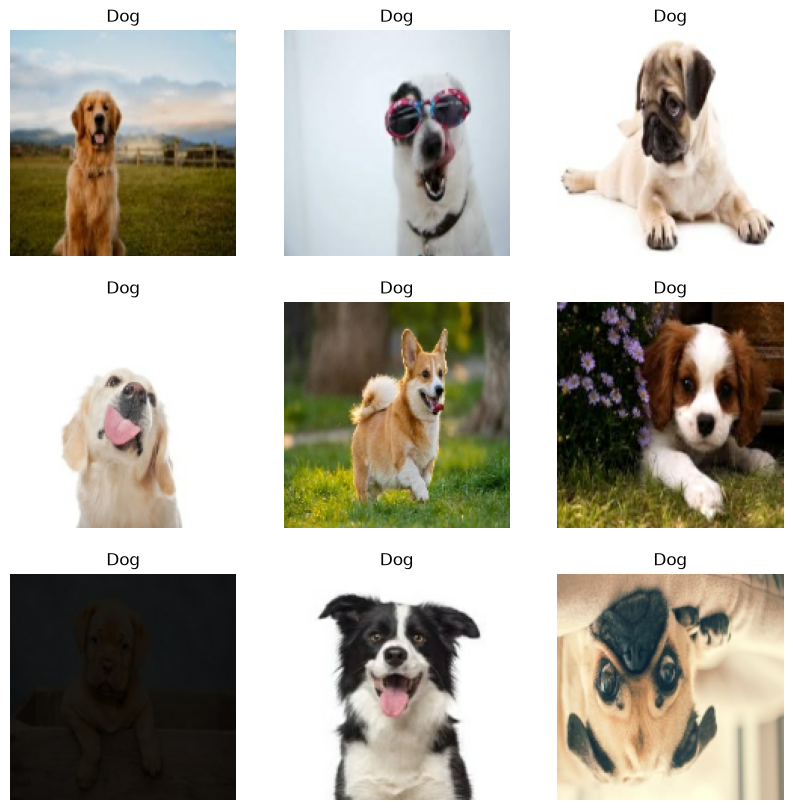

In [3]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

## 4. Build a Simple CNN Model
We construct a Convolutional Neural Network with alternating Conv2D and MaxPooling2D layers, followed by a Flatten layer and Dense layers for classification.

In [4]:
num_classes = 2

model = models.Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])


model.summary()

c:\Users\soory\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,678,178 (10.22 MB)

 Trainable params: 2,678,178 (10.22 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Compile and Train the Model
Compile the model with an Adam optimizer and SparseCategoricalCrossentropy loss, then fit it on the training data.

In [5]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

epochs = 10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/10


c:\Users\soory\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 331ms/step - accuracy: 0.5260 - loss: 0.9275 - val_accuracy: 0.5208 - val_loss: 0.6920
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step - accuracy: 0.5469 - loss: 0.6839 - val_accuracy: 0.4792 - val_loss: 0.6905
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.6615 - loss: 0.6526 - val_accuracy: 0.6250 - val_loss: 0.6631
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step - accuracy: 0.7031 - loss: 0.5941 - val_accuracy: 0.6667 - val_loss: 0.6196
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - accuracy: 0.7760 - loss: 0.5026 - val_accuracy: 0.6667 - val_loss: 0.5956
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - accuracy: 0.8021 - loss: 0.4350 - val_accuracy: 0.6458 - val_loss: 0.7101
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.8542 - loss: 0.3889 - val_accuracy: 0.7500 - val_loss: 0.5219
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - accuracy: 0.9115 - loss: 0.2895 - val_accuracy: 0.7083 - val_loss: 0.5814
Epo

## 6. Plot Accuracy and Loss Graphs
Visualize the training and validation accuracy and loss over epochs.

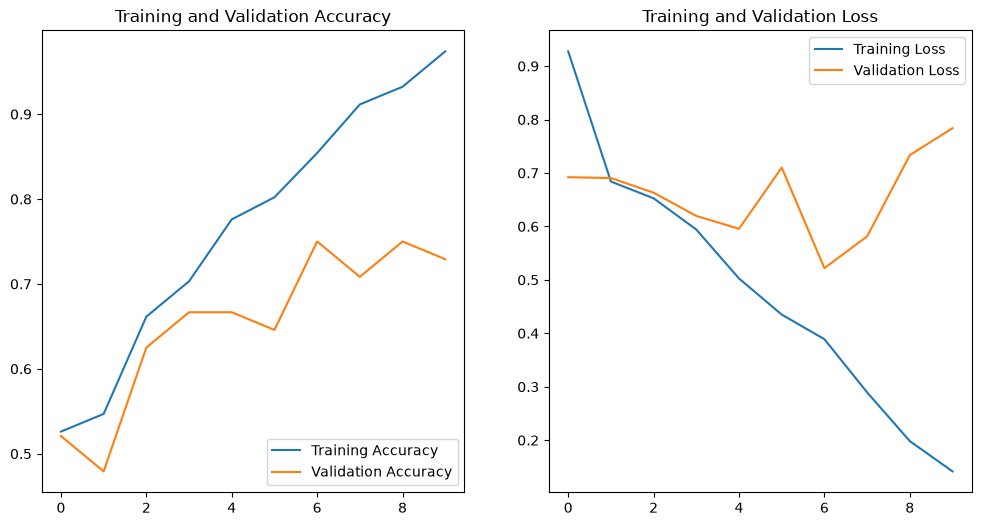

In [6]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## 7. Save the Trained Model
Save the model so we can use it later without retraining.

In [7]:
model.save('cat_dog_classifier.keras')
print("Model saved as 'cat_dog_classifier.keras'")

Model saved as 'cat_dog_classifier.keras'


## 8. Predict a New Image as Cat or Dog
Load a sample image, preprocess it, and use the trained model to predict its class.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
This image most likely belongs to Dog with a 54.27 percent confidence.


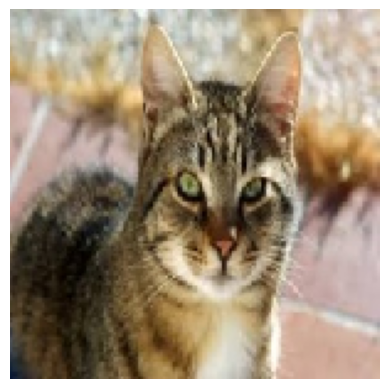

In [8]:
# Replace 'path/to/new/image.jpg' with an actual image path to test
test_image_path = 'dataset/Cat/Cat_1_1.jpg' # Example path

if os.path.exists(test_image_path):
    img = tf.keras.utils.load_img(test_image_path, target_size=(img_height, img_width))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) # Create a batch

    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])
    
    print(
        "This image most likely belongs to {} with a {:.2f} percent confidence."
        .format(class_names[np.argmax(score)], 100 * np.max(score))
    )
    
    # Display the image
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    print(f"Image not found at {test_image_path}. Please provide a valid path.")